In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("ruspini.csv")

In [4]:
X = df.drop(columns=['CLASS']).values
labels_true = LabelEncoder().fit_transform(df['CLASS'])

In [5]:
results = {}

In [6]:
linkage_methods = ['single', 'complete', 'average', 'centroid']

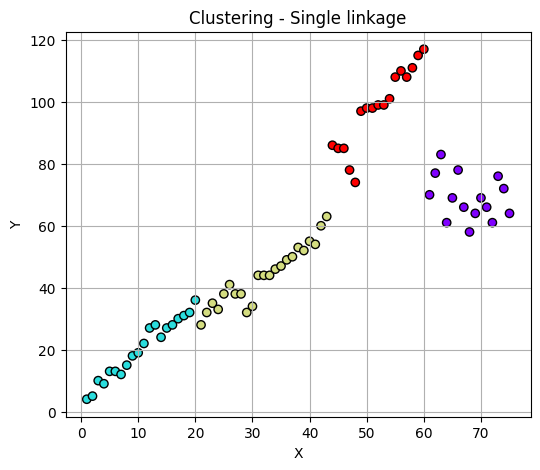

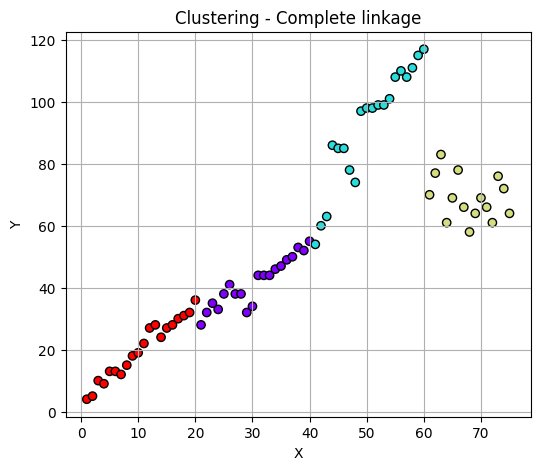

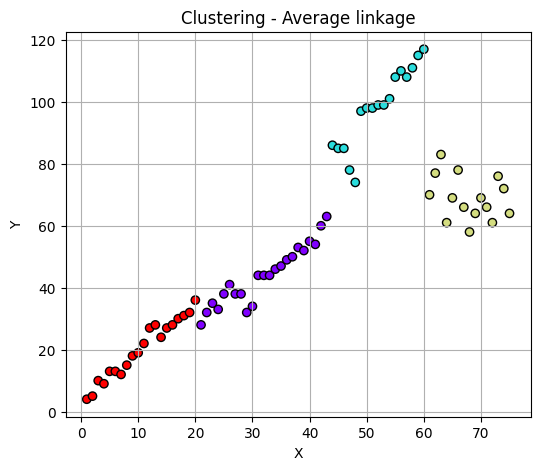

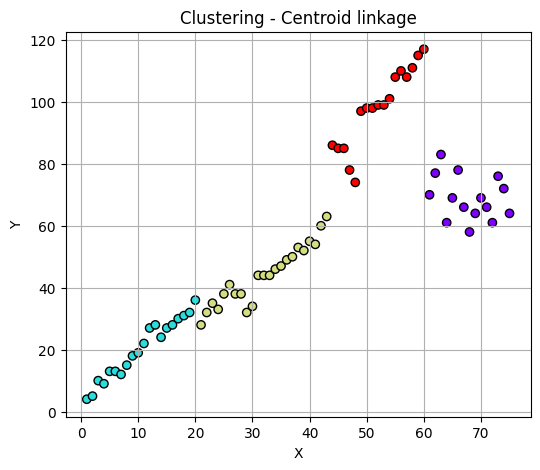

In [8]:
for method in linkage_methods:
    # 3. Buat linkage dan cluster
    Z = linkage(X, method=method)
    clusters = fcluster(Z, t=4, criterion='maxclust')  # karena ada 4 class asli

    # Simpan hasil
    results[method] = {'Z': Z, 'clusters': clusters}

    # 4. Visualisasi
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow', edgecolor='k')
    plt.title(f'Clustering - {method.title()} linkage')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

    # 5. Variance intra-cluster
    variance = 0
    for k in np.unique(clusters):
        cluster_points = X[clusters == k]
        centroid = np.mean(cluster_points, axis=0)
        variance += np.sum((cluster_points - centroid) ** 2)
    results[method]['variance'] = variance

    # 6. Error ratio (menggunakan confusion matrix)
    cm = confusion_matrix(labels_true, clusters)
    correct = np.sum(np.max(cm, axis=0))  # ambil maksimum tiap kolom (cluster)
    total = np.sum(cm)
    error_ratio = 1 - correct / total
    results[method]['error_ratio'] = error_ratio


In [9]:
variances = [res['variance'] for res in results.values()]
error_ratios = [res['error_ratio'] for res in results.values()]

avg_variance = np.mean(variances)
avg_error_ratio = np.mean(error_ratios)

In [10]:
print("\n📊 Rangkuman Hasil Clustering:")
for method, res in results.items():
    print(f"{method.title()} linkage → Variance: {res['variance']:.2f}, Error Ratio: {res['error_ratio']:.2f}")

print(f"\n📌 Rata-rata Variance: {avg_variance:.2f}")
print(f"📌 Rata-rata Error Ratio: {avg_error_ratio:.2f}")


📊 Rangkuman Hasil Clustering:
Single linkage → Variance: 15246.05, Error Ratio: 0.00
Complete linkage → Variance: 18534.58, Error Ratio: 0.04
Average linkage → Variance: 15246.05, Error Ratio: 0.00
Centroid linkage → Variance: 15246.05, Error Ratio: 0.00

📌 Rata-rata Variance: 16068.18
📌 Rata-rata Error Ratio: 0.01
